In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
dataset = pd.read_csv('Dataset/NatalityDataset.csv')

In [3]:
dataset.shape

(115056, 82)

In [4]:
cols = ['combgest',
 'gestrec10',
 'gestrec3',
 'lmpused',
 'oegest_comb',
 'oegest_r10',
 'oegest_r3']
for col in cols:
    print(col, sorted(dataset[col].unique()))

combgest [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 99]
gestrec10 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 99]
gestrec3 [1, 2, 3]
lmpused [nan]
oegest_comb [18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 99]
oegest_r10 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 99]
oegest_r3 [1, 2, 3]


,mage_impflg,mage_repflg,mager,mager14,mager9,mrace31,mrace6,mrace15,mraceimp,mar_p,...,setorder_r,compgst_imp,obgest_flg,combgest,gestrec10,gestrec3,lmpused,oegest_comb,oegest_r10,oegest_r3
84,NaN,NaN,29,9,4,5,5,12,NaN,Y,...,9,NaN,NaN,99,99,3,NaN,99,99,3
266,NaN,NaN,20,8,3,5,5,14,NaN,N,...,9,NaN,NaN,99,99,3,NaN,99,99,3
406,NaN,NaN,27,9,4,5,5,12,NaN,N,...,9,NaN,NaN,99,99,3,NaN,99,99,3
756,NaN,NaN,19,7,2,5,5,12,NaN,U,...,9,NaN,NaN,99,99,3,NaN,99,99,3
821,NaN,NaN,31,10,5,4,4,6,NaN,X,...,9,NaN,NaN,99,99,3,NaN,99,99,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114918,NaN,NaN,34,10,5,2,2,2,NaN,X,...,9,NaN,NaN,99,99,3,NaN,99,99,3
114956,NaN,NaN,23,8,3,2,2,2,NaN,N,...,9,NaN,NaN,99,99,3,NaN,99,99,3
114974,NaN,NaN,32,10,5,2,2,2,1.0,X,...,9,NaN,NaN,99,99,3,NaN,99,99,3
114983,NaN,NaN,35,11,6,2,2,2,NaN,N,...,9,NaN,NaN,99,99,3,NaN,99,99,3


In [6]:
dataset['combgest'] = dataset['combgest'].replace(99, pd.NA)
cleaned_dataset = dataset.dropna(subset=['combgest']).copy()
print(cleaned_dataset['combgest'].isnull().sum())

0


# Defining Preterm Target

In [7]:
cleaned_dataset['preterm'] = (cleaned_dataset['combgest']<37).astype(int)

In [8]:
cleaned_dataset['preterm'].value_counts()

0    98172
1    16446
Name: preterm, dtype: int64

In [9]:
target_leakage_cols = ['combgest', 'gestrec3', 'gestrec10', 'oegest_comb', 'oegest_r10', 'oegest_r3', 'obgest_flg', 'compgst_imp']
cleaned_dataset = cleaned_dataset.drop(columns=target_leakage_cols)

In [10]:
cleaned_dataset.shape

(114618, 75)

# Drop columns with >80% missing values¶

In [15]:
missing_90_cols = [col for col in cleaned_dataset.columns if cleaned_dataset[col].isnull().mean()>0.9]

In [16]:
cleaned_dataset = cleaned_dataset.drop(columns=missing_90_cols, errors='ignore')
print("Dropped columns:", missing_90_cols)
print("New shape:", cleaned_dataset.shape)

Dropped columns: ['mage_impflg', 'mage_repflg', 'mraceimp', 'mar_imp', 'fagerpt_flg', 'lmpused']
New shape: (114618, 69)


# Visualizing the preterm and not-preterm data¶

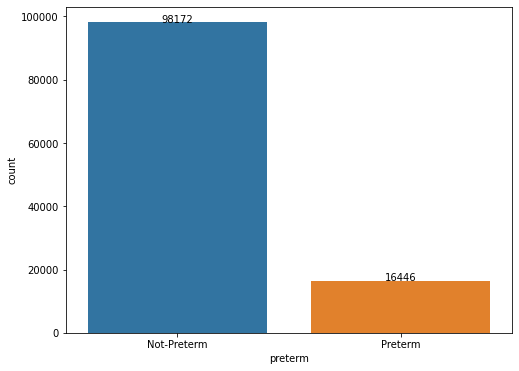

In [17]:
import seaborn as sns
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=cleaned_dataset, x='preterm')
plt.xticks([0, 1], ['Not-Preterm', 'Preterm'])
for p in ax.patches:
    # print(p)
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')
plt.savefig('BeforeSplitting.png', dpi=300)
plt.show()

In [18]:
unknown_code_map = {
    'mbstate_rec' : 3,'meduc' : 9,'fagecomb' : 99, 'fagerec11': 11, 'frace31': 99,'frace6': 9,'frace15': 99,'feduc': 9,'priorlive': 99,'priordead': 99,
    'priorterm': 99,'lbo_rec' : 9,'tbo_rec': 9,'illb_r': 999,'illb_r11': 99,'ilop_r': 999,
    'ilop_r11': 99,'ilp_r': 999,'ilp_r11': 99,'precare5': 5,'previs_rec': 12, 'cig_0': 99,'cig_1': 99,'cig_2': 99,'cig_3': 99,
    'cig0_r': 6,'cig1_r': 6,'cig2_r': 6,'cig3_r': 6,'m_ht_in': 99,
    'bmi': 99.9,'bmi_r': 9,'pwgt_r': 999,'dwgt_r':999,'wtgain': 99,'wtgain_rec': 9,'rf_cesarn': 99,'no_risks': 9,'no_infec': 9,
    'setorder_r': 9,'dlmp_mm': 99,'dlmp_yy': 9999      
    
}

In [19]:
cleaned_dataset.isnull().sum()[cleaned_dataset.isnull().sum()>0]

Series([], dtype: int64)

# Train Test split

In [42]:
X = cleaned_dataset.drop(columns=['preterm'])  # your features
y = cleaned_dataset['preterm']                 # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Visualizing the Preterm vs Not_Preterm in Train and Test

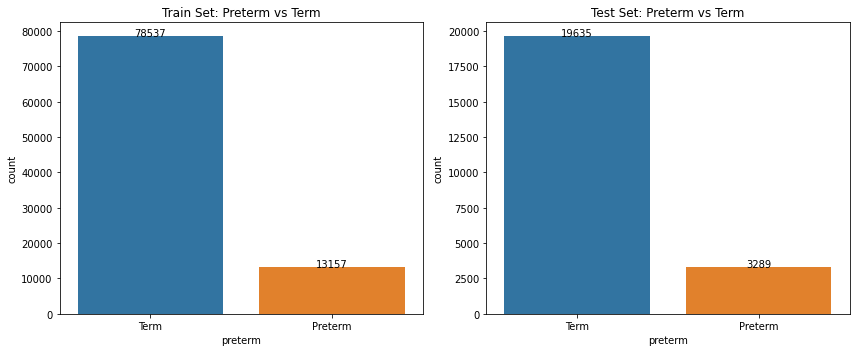

In [43]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Term','Preterm'])
axes[0].set_title('Train Set: Preterm vs Term')
for p in axes[0].patches:
    # print(p)
    height = p.get_height()
    axes[0].text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')

    

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['Term','Preterm'])
axes[1].set_title('Test Set: Preterm vs Term')
for p in axes[1].patches:
    # print(p)
    height = p.get_height()
    axes[1].text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')
plt.tight_layout()
plt.show()


In [44]:
numeric_cols = X_train.select_dtypes(include=['number']).columns
corr = X_train[numeric_cols].corr()

# Identify highly correlated pairs (threshold >0.9)
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.88:
            corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))

corr_pairs

[('mager14', 'mager', 0.9458521004254788),
 ('mager9', 'mager', 0.9719260565240037),
 ('mager9', 'mager14', 0.968183196413082),
 ('mrace6', 'mrace31', 0.923391954390761),
 ('mrace15', 'mrace31', 0.8976575237416262),
 ('mrace15', 'mrace6', 0.9658073700494644),
 ('fagerec11', 'fagecomb', 0.9436665621709754),
 ('frace6', 'frace31', 0.9263903175032998),
 ('frace15', 'frace31', 0.9982447650402352),
 ('frace15', 'frace6', 0.9443328734935332),
 ('illb_r11', 'illb_r', 0.9987948990749741),
 ('ilop_r11', 'ilop_r', 0.9993212295595864),
 ('ilp_r11', 'ilp_r', 0.999037125885458),
 ('cig_1', 'cig_0', 0.9960376611922233),
 ('cig_2', 'cig_0', 0.9959299982688319),
 ('cig_2', 'cig_1', 0.9987666679258314),
 ('cig_3', 'cig_0', 0.9288119910860193),
 ('cig_3', 'cig_1', 0.9305316215164807),
 ('cig_3', 'cig_2', 0.931361787909176),
 ('cig0_r', 'cig_0', 0.9945653110387002),
 ('cig0_r', 'cig_1', 0.9885101985630518),
 ('cig0_r', 'cig_2', 0.987911710785132),
 ('cig0_r', 'cig_3', 0.9212388938834956),
 ('cig1_r', 'ci

In [45]:
cols_to_drop = ['mager14', 'mager9', 'mrace31', 'mrace15', 'frace31', 'frace15',
                'lbo_rec', 'wtgain_rec', 'ilp_r11', 'ilop_r11', 'illb_r11', 'bmi_r', 'pwgt_r', 'fagerec11',
                'cig_3', 'cig_1', 'cig_0', 'cig_2']

In [46]:
X_train = X_train.drop(columns=cols_to_drop)
print(X_train.shape)


(91694, 50)


In [47]:
X_test = X_test.drop(columns = cols_to_drop)
print(X_test.shape)

(22924, 50)


In [48]:
X_train = X_train.drop(columns=['no_risks', 'no_infec', 'cig_rec', 'previs', 'precare'])
X_test = X_test.drop(columns=['no_risks', 'no_infec', 'cig_rec', 'previs', 'precare'])



In [51]:
X_train = X_train.drop(columns=['dwgt_r', 'ld_ster', 'setorder_r',
'ld_chor'])
X_test = X_test.drop(columns=['dwgt_r', 'ld_ster', 'setorder_r',
'ld_chor'])

In [52]:
print(X_train.shape)
print(X_test.shape)

(91694, 41)
(22924, 41)


# Step 1: Continuous / Numeric Features Preprocessing (12)

In [53]:
numeric_continuous_features = ['mager', 'fagecomb',
       'priorlive', 'priordead', 'priorterm', 'illb_r', 'ilop_r',
       'ilp_r', 'm_ht_in', 'bmi', 'wtgain', 'rf_cesarn']
len(numeric_continuous_features)

12

In [54]:
unknown_code_map = {
    'fagecomb' : 99, 'priorlive': 99,'priordead': 99,'priorterm': 99,'illb_r': 999,'ilop_r': 999,'ilp_r': 999,'m_ht_in': 99,
    'bmi': 99.9,'wtgain': 99,'rf_cesarn': 99
}
len(unknown_code_map)

11

In [55]:
for col, code in unknown_code_map.items():
    # Only apply to columns that exist in the dataset
    if col in cleaned_dataset.columns:
        X_train[col] = X_train[col].replace(code, pd.NA)

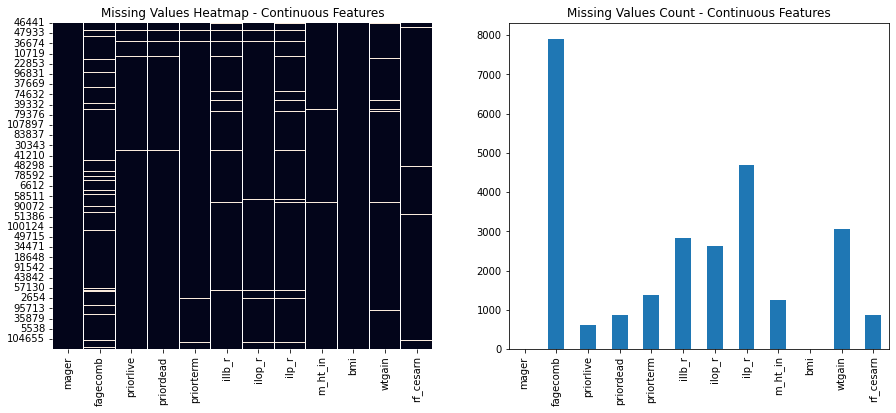

In [56]:
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
sns.heatmap(X_train[numeric_continuous_features].isna(), cbar=False)
plt.title("Missing Values Heatmap - Continuous Features")
# plt.show()

plt.subplot(1, 2, 2)
X_train[numeric_continuous_features].isna().sum().plot(kind='bar')
plt.title("Missing Values Count - Continuous Features")
plt.show()

In [39]:
(X_train[numeric_continuous_features].isnull().sum()/X_train.shape[0])*100

mager        0.000000
fagecomb     8.631972
priorlive    0.660894
priordead    0.938993
priorterm    1.501734
illb_r       3.076537
ilop_r       2.858420
ilp_r        5.109386
m_ht_in      1.374136
bmi          0.000000
wtgain       3.331734
rf_cesarn    0.945536
dtype: float64

# Step 2: Ordinal Features Preprocessing (11)

In [57]:
ordinal_features = ['meduc', 'feduc',  'cig0_r', 'cig1_r', 'cig2_r',
       'cig3_r',  'precare5', 'previs_rec',  'dplural', 'tbo_rec']
len(ordinal_features)

10

# Step 3: One-Hot Features (19)

In [58]:
all_features = X_train.columns.tolist()
one_hot_features = list(set(all_features) - set(numeric_continuous_features) - set(ordinal_features))
print(one_hot_features)
len(one_hot_features)

['ip_hepb', 'rf_pdiab', 'mrace6', 'rf_ghype', 'ip_chlam', 'rf_ppterm', 'rf_fedrg', 'rf_ehype', 'rf_phype', 'rf_inftr', 'rf_gdiab', 'rf_artec', 'ip_syph', 'ip_gon', 'mar_p', 'dmar', 'ip_hepc', 'rf_cesar', 'frace6']


19

# Build Preprocessing Pipeline

In [59]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [61]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = 'passthrough'

categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

In [62]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_pipeline, numeric_continuous_features),
        ('ord', ordinal_pipeline, ordinal_features),
        ('onehot', categorical_pipeline, one_hot_features)
    ]
)

In [63]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Train a Baseline Classifier (Random Forest)

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [65]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_processed, y_train)

RandomForestClassifier(random_state=42)

In [66]:
y_pred = clf.predict(X_test_processed)

In [67]:
# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.87

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     19635
           1       0.71      0.19      0.31      3289

    accuracy                           0.87     22924
   macro avg       0.80      0.59      0.62     22924
weighted avg       0.86      0.87      0.84     22924



In [68]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[19377   258]
 [ 2650   639]]


# Hyperparameter Tuning (Randomized Search / Grid Search)

In [69]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [70]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=[0,1], y=y_train)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

In [71]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42, class_weight=class_weights_dict)

rf_random = RandomizedSearchCV(
    estimator = rf,
    param_distributions = param_dist,
    n_iter = 15,
    scoring = 'roc_auc',
    cv = 3,
    verbose = 2,
    random_state = 42,
    n_jobs = -1
)

rf_random.fit(X_train_processed, y_train)

print("Best parameters:", rf_random.best_params_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}


In [ ]:
best_model = rf_random.best_estimator_
y_pred_best = best_model.predict(X_test_processed)

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))